# Crop Handwriting Image into Lines

## Attempt 6 - PDF input, auto-select lined page, marker warp, one cell


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Processing: whole image\sd.pdf
  Line scores: [94863, 48194]  ->  lined=page 1, blank=page 2
  Lined page: 2484 x 3509 px


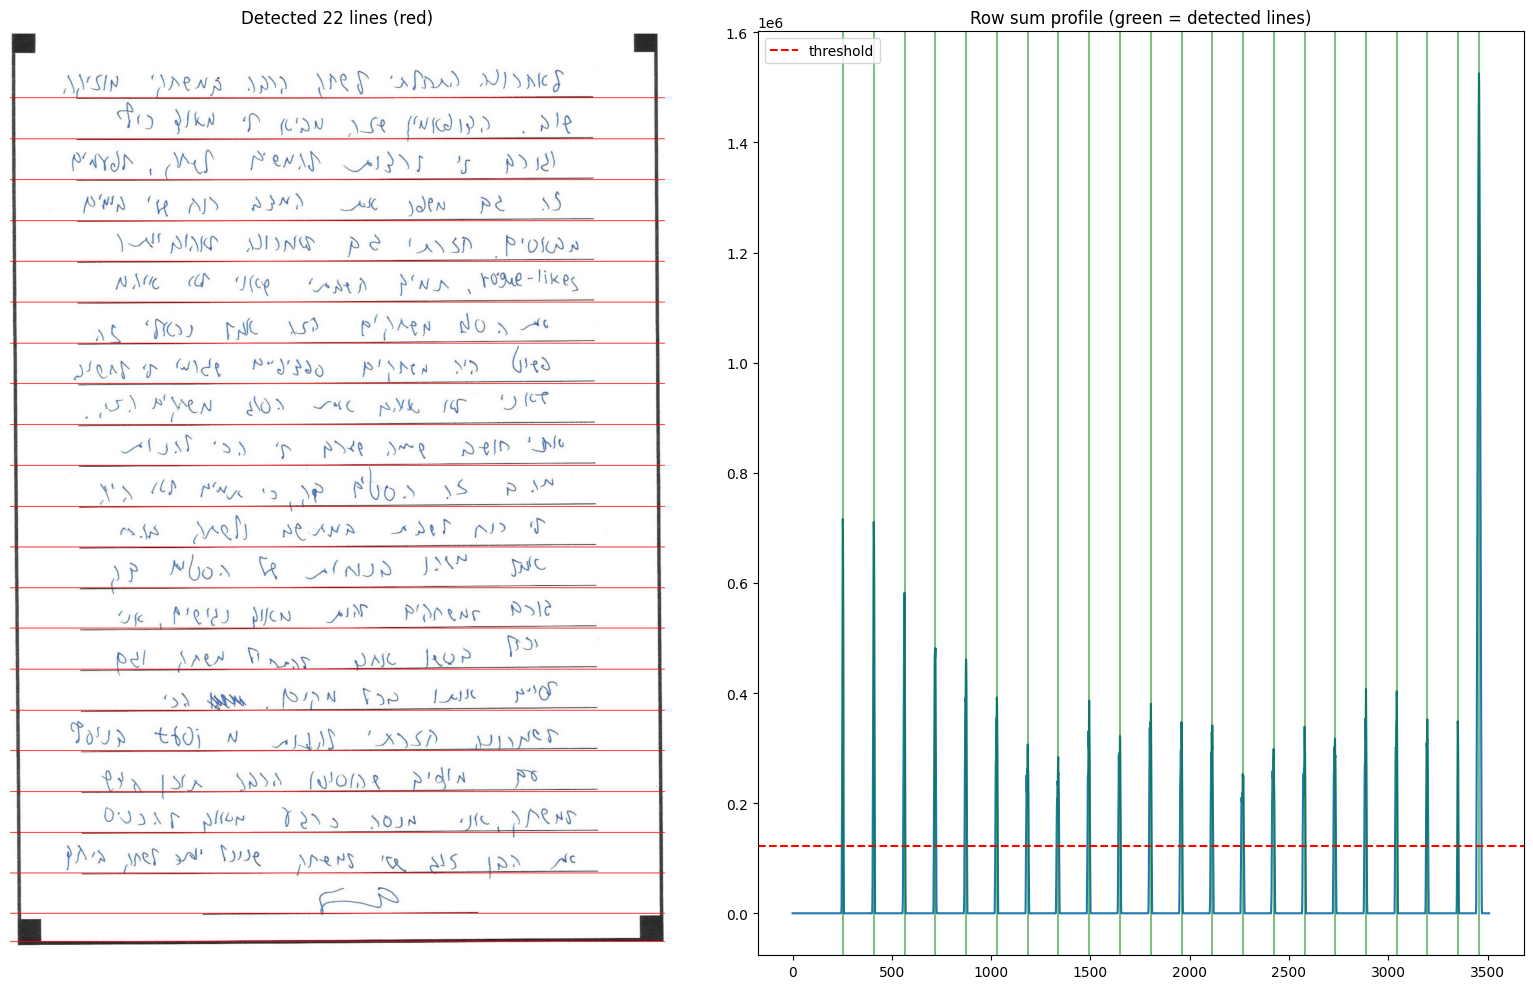

  Found 22 printed lines -> 21 crops
  Saved 21 line crops to 'cropped image to lines/attempt6'
  Blank page: 2484 x 3509 px
  Detected 3 column(s) -> saved sd_COLUMNS.png


In [4]:
!pip install pymupdf -q
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import fitz
from scipy.signal import find_peaks

INPUT_DIR  = "whole image"
OUT_DIR    = "cropped image to lines/attempt6"
os.makedirs(OUT_DIR, exist_ok=True)
OUTPUT_EXT   = ".png"
SKIP_TOP     = 10    # px to skip after the printed line (removes prev-row bleed)
PAD_BOTTOM   = 16   # px to add below the next printed line

# ── PDF loading ───────────────────────────────────────────────────────────────

def pdf_to_bgr_pages(path, dpi=300):
    doc   = fitz.open(path)
    scale = dpi / 72
    mat   = fitz.Matrix(scale, scale)
    pages = []
    for page in doc:
        pix = page.get_pixmap(matrix=mat)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR if pix.n == 4 else cv2.COLOR_RGB2BGR)
        pages.append(img)
    return pages

def horizontal_line_score(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    h, w = binary.shape
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(1, w // 5), 1))
    lines_only = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    return cv2.countNonZero(lines_only)

def select_pages(path, dpi=300):
    """Returns (lined_page, blank_page). blank_page is None if only 1 page."""
    pages = pdf_to_bgr_pages(path, dpi=dpi)
    if len(pages) == 1:
        print("  Single-page PDF — treating as lined, no blank page")
        return pages[0], None
    scores = [horizontal_line_score(p) for p in pages]
    lined_idx = int(np.argmax(scores))
    blank_idx = 1 - lined_idx
    print(f"  Line scores: {scores}  ->  lined=page {lined_idx+1}, blank=page {blank_idx+1}")
    return pages[lined_idx], pages[blank_idx]

# ── detect printed horizontal line positions ──────────────────────────────────

def detect_printed_lines(img, debug=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Use multiple kernel widths and sum their row projections so that
    # partially-covered lines (broken by handwriting) still get detected
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    row_sums = np.zeros(h, dtype=float)
    for kw in [w // 12, w // 8, w // 5]:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, 1))
        mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        row_sums += mask.sum(axis=1).astype(float)

    # Smooth to merge adjacent rows belonging to the same printed line
    from scipy.ndimage import uniform_filter1d
    row_sums = uniform_filter1d(row_sums, size=5)

    # Low threshold so faint lines aren't missed
    min_dist  = h // 50
    threshold = row_sums.max() * 0.08
    peaks, _  = find_peaks(row_sums, height=threshold, distance=min_dist)

    if debug:
        fig, axes = plt.subplots(1, 2, figsize=(16, 10))
        vis = img.copy()
        for y in peaks:
            cv2.line(vis, (0, int(y)), (w, int(y)), (0, 0, 255), 2)
        axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Detected {len(peaks)} lines (red)")
        axes[0].axis("off")
        axes[1].plot(row_sums)
        axes[1].axhline(threshold, color="r", linestyle="--", label="threshold")
        for y in peaks:
            axes[1].axvline(y, color="g", alpha=0.5)
        axes[1].set_title("Row sum profile (green = detected lines)")
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    return sorted(peaks.tolist())

# ── crop between lines ────────────────────────────────────────────────────────

def crop_lines(img, line_ys, out_dir, basename, skip_top=SKIP_TOP, pad_bottom=PAD_BOTTOM):
    h, w = img.shape[:2]
    saved = 0
    for i in range(len(line_ys) - 1):
        y1 = min(h, line_ys[i]     + skip_top)   # start just after the printed line
        y2 = min(h, line_ys[i + 1] + pad_bottom) # show a bit below the next line
        crop = img[y1:y2, :]
        name = f"{basename}_line_{i+1:02d}{OUTPUT_EXT}"
        cv2.imwrite(os.path.join(out_dir, name), crop)
        saved += 1
    return saved

# ── column detection (blank page) ─────────────────────────────────────────────

COLUMN_TOKEN = "_COLUMNS"   # filename tag — filter by this in other notebooks

def column_detection(img, out_dir, basename):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # Binarize
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Remove any blob that touches the image boundary — that is always the
    # corner markers, regardless of scan size or margin width
    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    clean = binary.copy()
    for lbl in range(1, n):
        x = stats[lbl, cv2.CC_STAT_LEFT]
        y = stats[lbl, cv2.CC_STAT_TOP]
        bw = stats[lbl, cv2.CC_STAT_WIDTH]
        bh = stats[lbl, cv2.CC_STAT_HEIGHT]
        touches_border = (x == 0 or y == 0 or x + bw >= w or y + bh >= h)
        if touches_border:
            clean[labels == lbl] = 0

    # Column projection on the cleaned binary
    from scipy.ndimage import uniform_filter1d
    col_sums = clean.sum(axis=0).astype(float)
    col_sums = uniform_filter1d(col_sums, size=w // 40)

    threshold = col_sums.max() * 0.05
    in_col = col_sums > threshold

    bands, start = [], None
    for x, val in enumerate(in_col):
        if val and start is None:
            start = x
        elif not val and start is not None:
            bands.append([start, x])
            start = None
    if start is not None:
        bands.append([start, w])

    # Merge bands separated by less than 2% of width
    merged, min_gap = [], w // 50
    for band in bands:
        if merged and band[0] - merged[-1][1] < min_gap:
            merged[-1][1] = band[1]
        else:
            merged.append(band)

    merged = sorted(merged, key=lambda b: b[0])

    # Build bounding boxes
    boxes = []
    for x1, x2 in merged:
        strip = clean[:, x1:x2]
        ys = np.where(strip.sum(axis=1) > 0)[0]
        if len(ys) == 0:
            continue
        boxes.append((x1, int(ys[0]), x2, int(ys[-1])))

    # Draw and save
    vis = img.copy()
    for idx, (x1, y1, x2, y2) in enumerate(boxes):
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 3)
        cv2.putText(vis, f"col {idx+1}", (x1 + 4, y1 + 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

    out_name = f"{basename}{COLUMN_TOKEN}.png"
    cv2.imwrite(os.path.join(out_dir, out_name), vis)
    print(f"  Detected {len(boxes)} column(s) -> saved {out_name}")
    return boxes

# ── run ───────────────────────────────────────────────────────────────────────

pdf_files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.pdf")))
if not pdf_files:
    raise FileNotFoundError(f"No PDF files found in {INPUT_DIR!r}")

for pdf_path in pdf_files:
    base = os.path.splitext(os.path.basename(pdf_path))[0]
    print()
    print(f"Processing: {pdf_path}")

    lined_page, blank_page = select_pages(pdf_path)

    # ── lined page -> crop by printed lines ───────────────────────────────
    print(f"  Lined page: {lined_page.shape[1]} x {lined_page.shape[0]} px")
    line_ys = detect_printed_lines(lined_page, debug=True)
    print(f"  Found {len(line_ys)} printed lines -> {len(line_ys)-1} crops")
    if len(line_ys) < 2:
        print("  Not enough lines detected — skipping lined page")
    else:
        n = crop_lines(lined_page, line_ys, OUT_DIR, base)
        print(f"  Saved {n} line crops to {OUT_DIR!r}")

    # ── blank page -> column detection ────────────────────────────────────
    if blank_page is not None:
        print(f"  Blank page: {blank_page.shape[1]} x {blank_page.shape[0]} px")
        column_detection(blank_page, OUT_DIR, base)
